# 04. 이상 탐지 모델링

3가지 비지도 학습 모델을 적용하여 선박 이상 행동을 탐지한다.

| 모델 | 원리 | 장점 |
|------|------|------|
| Isolation Forest | 랜덤 분할로 이상치 격리 | 고차원, 대용량에 강함 |
| DBSCAN | 밀도 기반 클러스터링 | 임의 형태 클러스터 탐지 |
| LOF | 지역 밀도 비교 | 국소적 이상치에 강함 |

최종: 3개 모델 앙상블 (2개 이상 동의 시 이상 판정)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.models import (
    detect_isolation_forest, detect_lof, detect_dbscan,
    ensemble_anomaly, FEATURE_COLS
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

In [2]:
df = pd.read_parquet('../data/ais_featured.parquet')
print(f'{len(df):,} rows, {df["MMSI"].nunique()} vessels')

# 결측치 제거 (피처 컬럼 기준)
df_model = df.dropna(subset=FEATURE_COLS).copy()
print(f'모델 입력: {len(df_model):,} rows (결측 제거 후)')

630,026 rows, 500 vessels
모델 입력: 629,526 rows (결측 제거 후)


## 4.1 Isolation Forest

In [3]:
df_model = detect_isolation_forest(df_model, contamination=0.05)

n_anomaly = df_model['anomaly_if'].sum()
print(f'Isolation Forest 이상 탐지: {n_anomaly:,} ({n_anomaly/len(df_model)*100:.2f}%)')

Isolation Forest 이상 탐지: 31,477 (5.00%)


## 4.2 Local Outlier Factor

In [4]:
df_model = detect_lof(df_model, contamination=0.05)

n_anomaly = df_model['anomaly_lof'].sum()
print(f'LOF 이상 탐지: {n_anomaly:,} ({n_anomaly/len(df_model)*100:.2f}%)')

LOF 이상 탐지: 31,477 (5.00%)


C:\Users\ybs12\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


## 4.3 DBSCAN

In [5]:
df_model = detect_dbscan(df_model, eps=1.5, min_samples=20)

n_anomaly = df_model['anomaly_dbscan'].sum()
print(f'DBSCAN 이상 탐지: {n_anomaly:,} ({n_anomaly/len(df_model)*100:.2f}%)')

DBSCAN 이상 탐지: 3,804 (0.60%)


## 4.4 모델 간 비교

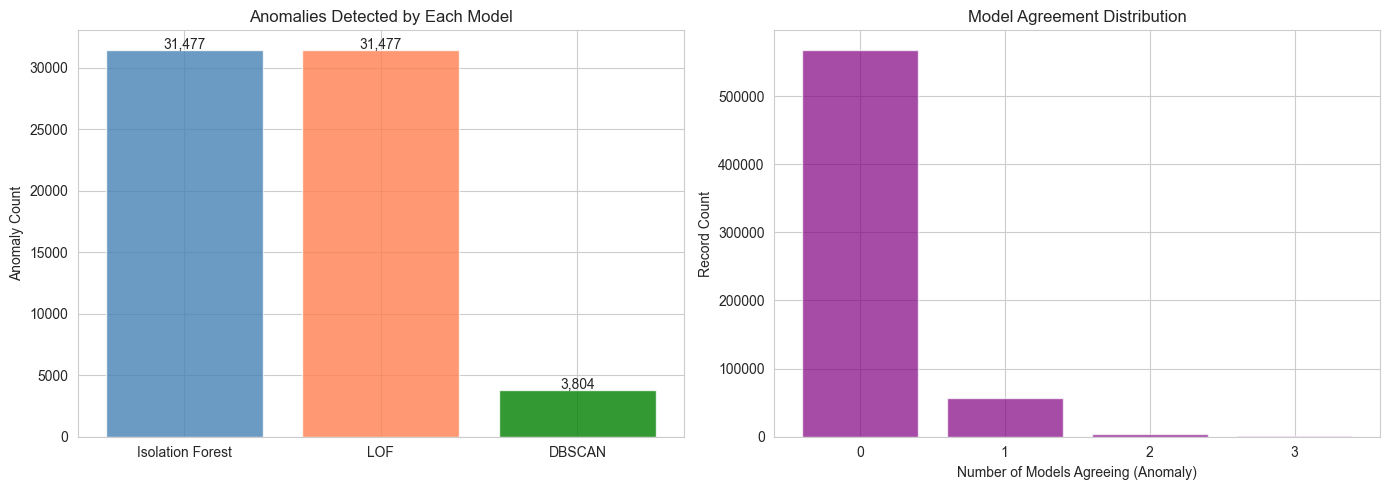

In [6]:
anomaly_cols = ['anomaly_if', 'anomaly_lof', 'anomaly_dbscan']
model_names = ['Isolation Forest', 'LOF', 'DBSCAN']

# 모델별 이상 탐지 수
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = [df_model[c].sum() for c in anomaly_cols]
axes[0].bar(model_names, counts, color=['steelblue', 'coral', 'green'], alpha=0.8)
axes[0].set_ylabel('Anomaly Count')
axes[0].set_title('Anomalies Detected by Each Model')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center')

# 모델 간 합의
agreement = df_model[anomaly_cols].sum(axis=1).value_counts().sort_index()
axes[1].bar(agreement.index, agreement.values, color='purple', alpha=0.7)
axes[1].set_xlabel('Number of Models Agreeing (Anomaly)')
axes[1].set_ylabel('Record Count')
axes[1].set_title('Model Agreement Distribution')
axes[1].set_xticks([0, 1, 2, 3])

plt.tight_layout()
plt.savefig('../results/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 앙상블 (최종 판정)

In [7]:
df_model = ensemble_anomaly(df_model, threshold=2)

n_final = df_model['anomaly_final'].sum()
n_vessels = df_model[df_model['anomaly_final'] == 1]['MMSI'].nunique()

print(f'=== 최종 앙상블 결과 ===')
print(f'이상 레코드: {n_final:,} / {len(df_model):,} ({n_final/len(df_model)*100:.2f}%)')
print(f'이상 선박: {n_vessels} / {df_model["MMSI"].nunique()}')

=== 최종 앙상블 결과 ===
이상 레코드: 4,907 / 629,526 (0.78%)
이상 선박: 479 / 500


## 4.6 이상 탐지 결과 분석

In [8]:
# 정상 vs 이상 피처 비교
normal = df_model[df_model['anomaly_final'] == 0]
anomaly = df_model[df_model['anomaly_final'] == 1]

print('=== 정상 vs 이상 피처 평균 비교 ===')
comparison = pd.DataFrame({
    'Normal': normal[FEATURE_COLS].mean(),
    'Anomaly': anomaly[FEATURE_COLS].mean(),
    'Ratio': anomaly[FEATURE_COLS].mean() / normal[FEATURE_COLS].mean().replace(0, 1)
})
print(comparison.round(2))

=== 정상 vs 이상 피처 평균 비교 ===
                 Normal  Anomaly   Ratio
SOG                2.26     8.05    3.57
speed_deviation   -0.02     2.57 -126.91
course_change     21.28    53.17    2.50
signal_gap_sec    68.49    80.99    1.18
is_night           0.33     0.50    1.52


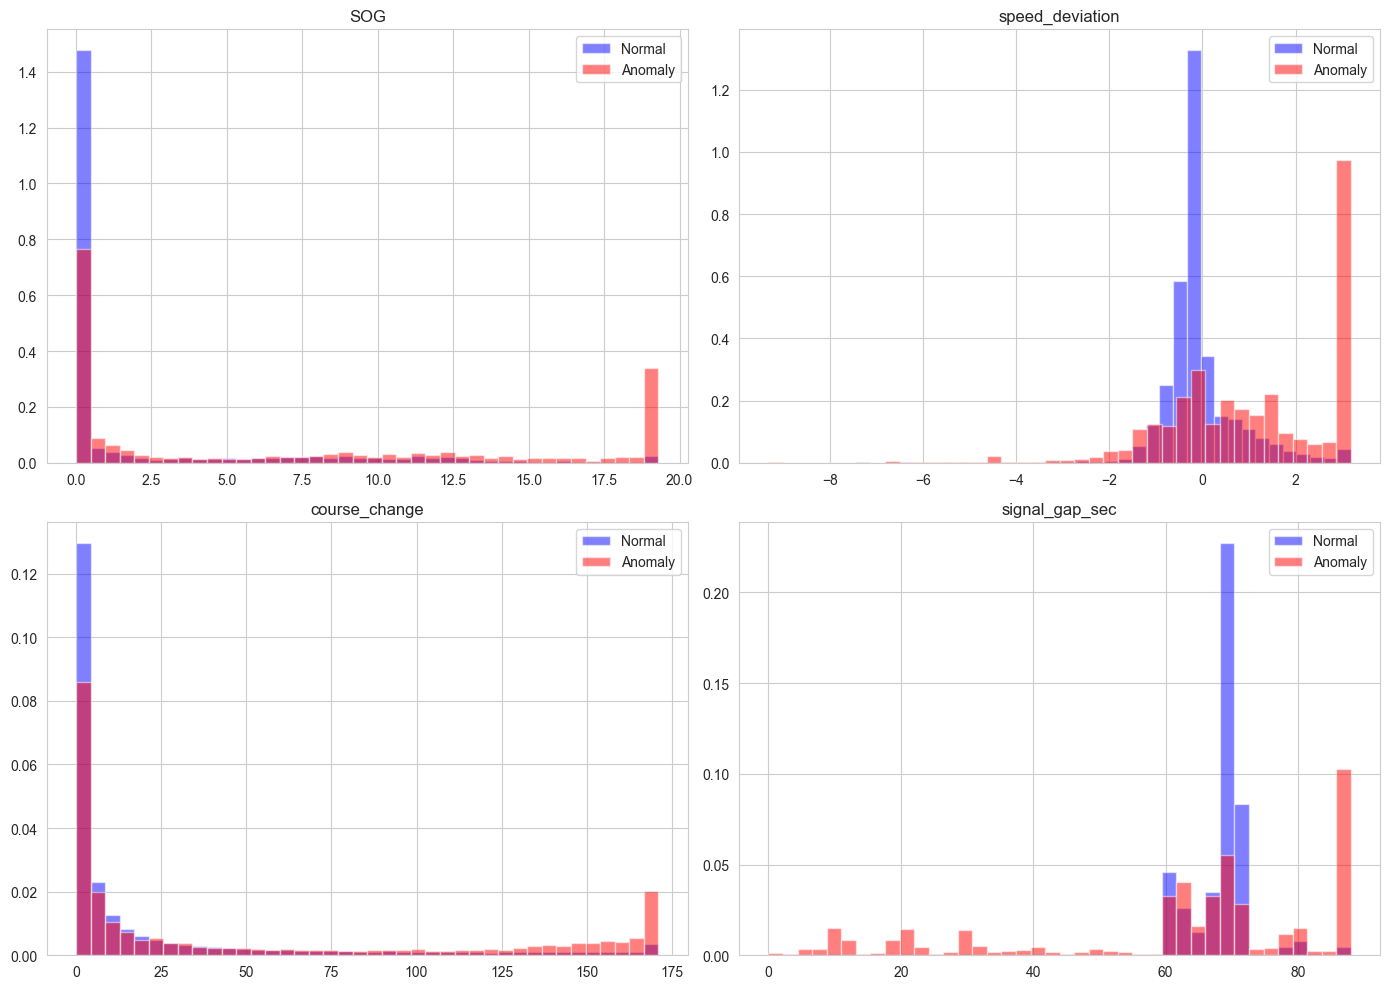

In [9]:
# 피처별 정상 vs 이상 분포 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(['SOG', 'speed_deviation', 'course_change', 'signal_gap_sec']):
    ax = axes[idx // 2, idx % 2]
    clip_val = normal[col].quantile(0.99)
    normal[col].clip(upper=clip_val).hist(bins=40, ax=ax, alpha=0.5, color='blue', label='Normal', density=True)
    anomaly[col].clip(upper=clip_val).hist(bins=40, ax=ax, alpha=0.5, color='red', label='Anomaly', density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/normal_vs_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6.1 피처 중요도 (Permutation Importance)

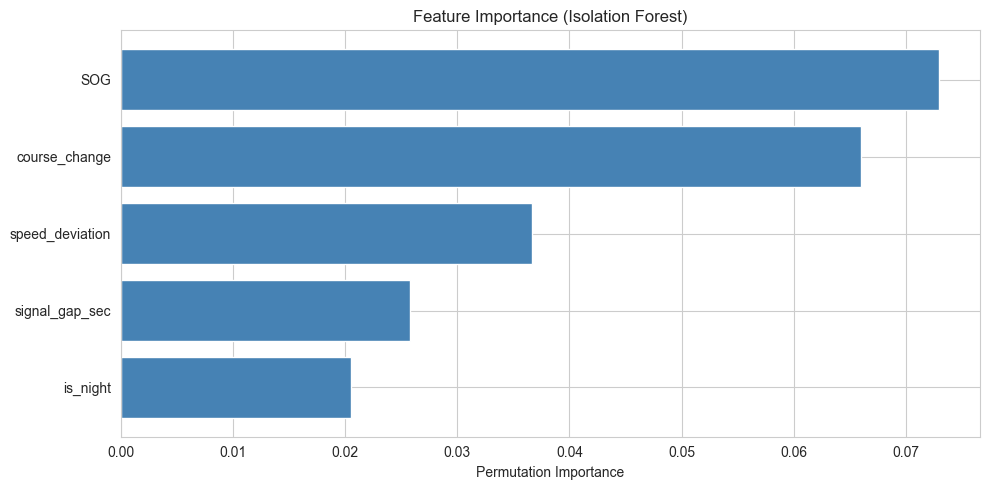

        feature  importance
       is_night    0.020479
 signal_gap_sec    0.025768
speed_deviation    0.036623
  course_change    0.066050
            SOG    0.072978


In [10]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import IsolationForest
from sklearn.metrics import make_scorer
from src.models import prepare_features, FEATURE_COLS

# Isolation Forest 모델 재학습
X, _ = prepare_features(df_model)
if_model = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
if_model.fit(X)
y_pred = if_model.predict(X)

# Permutation Importance
def anomaly_scorer(estimator, X, y):
    return (estimator.predict(X) == y).mean()

perm_result = permutation_importance(
    if_model, X, y_pred,
    scoring=anomaly_scorer,
    n_repeats=10, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_xlabel('Permutation Importance')
ax.set_title('Feature Importance (Isolation Forest)')

plt.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))

## 4.6.2 contamination 민감도 분석

contamination(오염 비율)을 바꾸면 결과가 얼마나 달라지는지 확인한다.

In [11]:
# contamination 변화에 따른 앙상블 이상 탐지 수 변화
from src.models import prepare_features
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

df_sens = pd.read_parquet('../data/ais_featured.parquet').dropna(subset=FEATURE_COLS).copy()
X, _ = prepare_features(df_sens)

contamination_values = [0.01, 0.03, 0.05, 0.07, 0.10]
results = []

for cont in contamination_values:
    # IF
    if_model = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    if_pred = (if_model.fit_predict(X) == -1).astype(int)
    
    # LOF
    lof_model = LocalOutlierFactor(contamination=cont, n_jobs=-1)
    lof_pred = (lof_model.fit_predict(X) == -1).astype(int)
    
    # DBSCAN은 contamination 파라미터가 없으므로 고정
    dbscan_pred = df_model['anomaly_dbscan'].values
    
    ensemble = (if_pred + lof_pred + dbscan_pred) >= 2
    results.append({
        'contamination': cont,
        'IF': if_pred.sum(),
        'LOF': lof_pred.sum(),
        'Ensemble (2/3)': ensemble.sum(),
        'Ensemble %': f'{ensemble.sum() / len(X) * 100:.2f}%'
    })

sens_df = pd.DataFrame(results)
print(sens_df.to_string(index=False))

C:\Users\ybs12\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


C:\Users\ybs12\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


C:\Users\ybs12\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


C:\Users\ybs12\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


 contamination    IF   LOF  Ensemble (2/3) Ensemble %
          0.01  6296  6284            1445      0.23%
          0.03 18886 18886            2888      0.46%
          0.05 31477 31477            4907      0.78%
          0.07 44066 44067            7434      1.18%
          0.10 62953 62953           12678      2.01%


C:\Users\ybs12\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


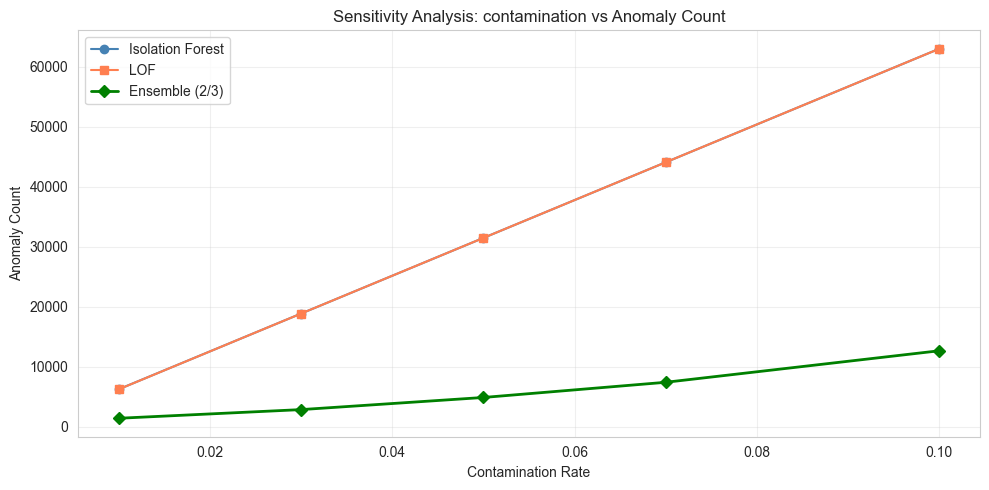

contamination=0.05 기준 앙상블: 4,907건
범위: 1,445 ~ 12,678건


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot([r['contamination'] for r in results],
        [r['IF'] for r in results], 'o-', label='Isolation Forest', color='steelblue')
ax.plot([r['contamination'] for r in results],
        [r['LOF'] for r in results], 's-', label='LOF', color='coral')
ax.plot([r['contamination'] for r in results],
        [r['Ensemble (2/3)'] for r in results], 'D-', label='Ensemble (2/3)', color='green', linewidth=2)

ax.set_xlabel('Contamination Rate')
ax.set_ylabel('Anomaly Count')
ax.set_title('Sensitivity Analysis: contamination vs Anomaly Count')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

chosen = sens_df[sens_df['contamination']==0.05]['Ensemble (2/3)'].values[0]
print(f'contamination=0.05 기준 앙상블: {chosen:,}건')
print(f'범위: {sens_df["Ensemble (2/3)"].min():,} ~ {sens_df["Ensemble (2/3)"].max():,}건')

## 4.7 결과 저장

In [13]:
df_model.to_parquet('../data/ais_results.parquet', index=False)

import os
fsize = os.path.getsize('../data/ais_results.parquet') / 1e6
print(f'저장 완료: data/ais_results.parquet ({fsize:.1f} MB)')

저장 완료: data/ais_results.parquet (10.7 MB)
